# <span style="color:darkblue"> Assignment 2 </span>

### <span style="color:darkblue"> Joelle Millar, September 2026 </span>

# Formula 1 Statistics, 1981 - 2020

### TODO SUMMARISE FINDINGS

## Set up - Import libraries

In [2]:
# TODO check that both of these libraries are used
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

TODO write python code for checking there are no missing values and that the datasets are ready to be merged etc
Comment out where you print the head or tail of the data to view

## a) i. Which 3 constructors earned the most points between 1981 and 2020?


In [3]:
# QUESTION - does it mean which 3 constructors had the highest number of points in one season between those years
# or which 3 earned the most accumulative points in those years based on the points standing at the end of each season

# Read the required files
constructors = pd.read_csv('data_raw/constructors.csv')
constructor_standings = pd.read_csv('data_raw/constructor_standings.csv')
races = pd.read_csv('data_raw/races.csv')

# Merge constructor_standings with races to get the year 
constructor_data = constructor_standings.merge(
    races[['raceId', 'year', 'round']],
    on='raceId'
)

# Only keep races between 1981 and 2020
constructor_data = constructor_data[
    (constructor_data['year'] >= 1981) &
    (constructor_data['year'] <= 2020)
]

# Sort by constructor, year, and race round
constructor_data = constructor_data.sort_values(
    ['constructorId', 'year', 'round']
)

# Keep the final standings for each constructor in each season
final_points_per_season = (
    constructor_data
    .groupby(['constructorId', 'year'])
    .tail(1)
)

# Add each constructor's final season points across all seasons
total_points = (
    final_points_per_season
    .groupby('constructorId')['points']
    .sum()
    .reset_index(name='Total Points')
)

# Add constructor names and find the top 3
top_3 = (
    total_points
    .merge(
        constructors[['constructorId', 'name']],
        on='constructorId'
    )
    .sort_values('Total Points', ascending=False)
    .reset_index()
    .head(3)
)

top_3.insert(
    0,
    'Ranking',
    range(1, len(top_3) + 1)
)

# Reename the name column
top_3 = top_3.rename(
    columns={'name' : 'Constructor'}
)

# Display only Ranking and Constructor columns
top_3_ranking = top_3[
    ['Ranking', 'Constructor']
]

# Display the table
top_3_ranking.style.hide(axis='index') \
    .set_caption(
        'Top 3 Constructors by total points, 1981 - 2020'
    )



Ranking,Constructor
1,Ferrari
2,Mercedes
3,McLaren


## a) ii. How many total points did each of them earn?

In [4]:

# Add constructor names and find the top 3
top_3_points = top_3[
    ['Ranking', 'Constructor', 'Total Points']
]

# Display the table
top_3_points.style.hide(axis='index') \
    .format({'Total Points': '{:,.0f}'}) \
    .set_caption(
        'Top 3 Constructors by total points, 1981 - 2020'
    )


Ranking,Constructor,Total Points
1,Ferrari,"7,374"
2,Mercedes,"5,685"
3,McLaren,"5,230"


## a) iii. How do the total points for each constructor compare with the average across constructors?

Average total points: 539.1818181818181


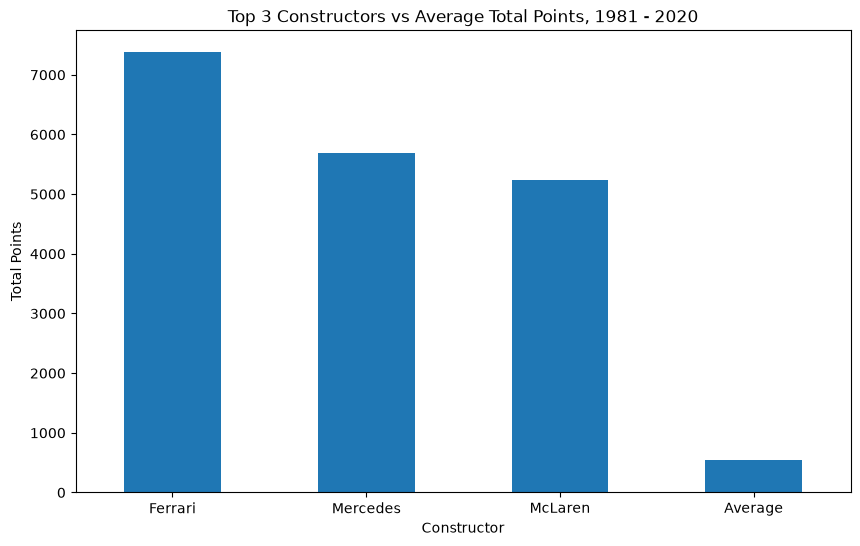

In [5]:
# QUESTION does it mean average across all constructors for 1981 and 2020 or for all years?

# Calculate the average total points across all constructors
average_points = total_points['Total Points'].mean()
print("Average total points:", average_points)

# Add constructor names
top_3_comparison = (
    top_3
    [['Ranking', 'Constructor', 'Total Points']]
    .copy()
)

# Calculate difference between top 3 and the average
top_3_comparison['Difference from Average'] = (
    top_3_comparison['Total Points'] - average_points
)

top_3_comparison.style.hide(axis='index') \
    .format({
        'Total Points': '{:,.0f}',
        'Difference from Average': '{:,.0f}'
    }) \
    .set_caption(
        'Top 3 Constructors Compared with Average Total Points, 1981 - 2020'
    )


# Create data for the chart
chart_data = top_3_comparison[
    ['Constructor', 'Total Points']
].copy()

# Add the average as another category
chart_data.loc[len(chart_data)] = [
    'Average',
    average_points
]

# Plot
chart_data.plot(
    x='Constructor',
    y='Total Points',
    kind='bar',
    figsize=(10, 6),
    legend=False
)

plt.title('Top 3 Constructors vs Average Total Points, 1981 - 2020')
plt.xlabel('Constructor')
plt.ylabel('Total Points')
plt.xticks(rotation=0)
plt.show()

## b) i. Which 3 constructors earned the most points between 2001 and 2020?

In [6]:
# Keep races between 2001 and 2020
constructor_data = constructor_data[
    (constructor_data['year'] >= 2001) &
    (constructor_data['year'] <= 2020)
]

# Sort by constructor, year, and race round
constructor_data = constructor_data.sort_values(
    ['constructorId', 'year', 'round']
)

# Keep the final standings for each constructor in each season
final_points_per_season = (
    constructor_data
    .groupby(['constructorId', 'year'])
    .tail(1)
)

# Add each constructor's final season points across all seasons
total_points = (
    final_points_per_season
    .groupby('constructorId')['points']
    .sum()
    .reset_index(name='Total Points')
)

# Add constructor names and find the top 3
top_3_2001 = (
    total_points
    .merge(
        constructors[['constructorId', 'name']],
        on='constructorId'
    )
    .sort_values('Total Points', ascending=False)
    .reset_index()
    .head(3)
)

top_3_2001.insert(
    0,
    'Ranking',
    range(1, len(top_3) + 1)
)

# Reename the name column
top_3_2001 = top_3_2001.rename(
    columns={'name' : 'Constructor'}
)

# Display only Ranking and Constructor columns
top_3_2001_ranking = top_3_2001[
    ['Ranking', 'Constructor']
]

# Display the table
top_3_2001_ranking.style.hide(axis='index') \
    .set_caption(
        'Top 3 Constructors by total points, 2001 - 2020'
    )




Ranking,Constructor
1,Ferrari
2,Mercedes
3,Red Bull


## b) ii. How many total points did each of them earn?

In [9]:

# Add constructor names and find the top 3
top_3__2001_points = top_3_2001[
    ['Ranking', 'Constructor', 'Total Points']
]

# Display the table
top_3__2001_points.style.hide(axis='index') \
    .format({'Total Points': '{:,.0f}'}) \
    .set_caption(
        'Top 3 Constructors by total points, 2001 - 2020'
    )


Ranking,Constructor,Total Points
1,Ferrari,"5,862"
2,Mercedes,"5,685"
3,Red Bull,"5,044"


## b) iii. How do the total points for each constructor compare with the average across constructors?

Average total points: 783.9


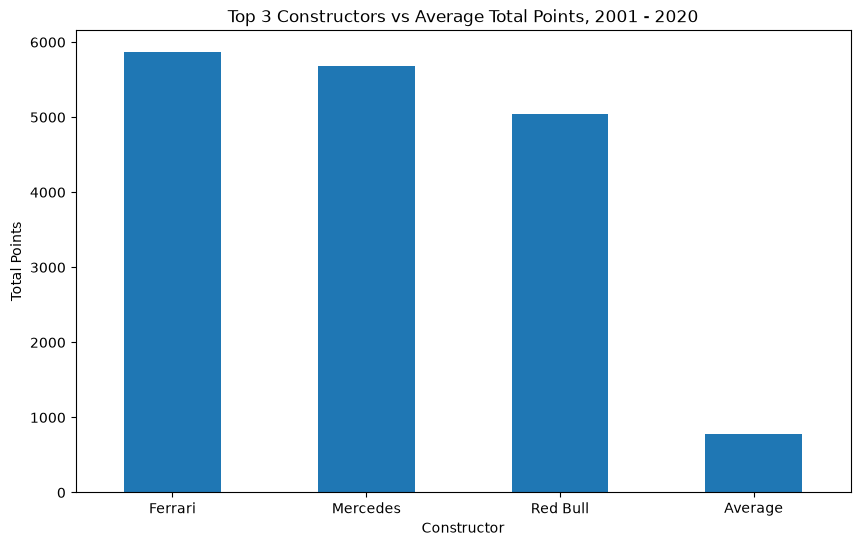

In [10]:
# Calculate the average total points across all constructors
average_points = total_points['Total Points'].mean()
print("Average total points:", average_points)

# Add constructor names
top_3_comparison = (
    top_3_2001
    [['Ranking', 'Constructor', 'Total Points']]
    .copy()
)

# Calculate difference between top 3 and the average
top_3_comparison['Difference from Average'] = (
    top_3_comparison['Total Points'] - average_points
)

top_3_comparison.style.hide(axis='index') \
    .format({
        'Total Points': '{:,.0f}',
        'Difference from Average': '{:,.0f}'
    }) \
    .set_caption(
        'Top 3 Constructors Compared with Average Total Points, 2001 - 2020'
    )


# Create data for the chart
chart_data = top_3_comparison[
    ['Constructor', 'Total Points']
].copy()

# Add the average as another category
chart_data.loc[len(chart_data)] = [
    'Average',
    average_points
]

# Plot
chart_data.plot(
    x='Constructor',
    y='Total Points',
    kind='bar',
    figsize=(10, 6),
    legend=False
)

plt.title('Top 3 Constructors vs Average Total Points, 2001 - 2020')
plt.xlabel('Constructor')
plt.ylabel('Total Points')
plt.xticks(rotation=0)
plt.show()

## c) How did the rankings change across the 2 time periods?

In [27]:
# Add ranking to each time period
top_3['rank_1981_2020'] = range(1, 4)
top_3_2001['rank_2001_2020'] = range(1, 4)

print(top_3)
print(top_3_2001)

# Rename points columns for each period
top_3 = top_3.rename(
    columns={'Total Points': 'points_1981_2020'}
)

top_3_2001 = top_3_2001.rename(
    columns={'Total Points': 'points_2001_2020'}
)

print(top_3)
print(top_3_2001)

# Merge the two periods
comparison = top_3[
    ['Constructor', 'rank_1981_2020', 'points_1981_2020']
    ].merge(
    top_3_2001[
        ['Constructor', 'rank_2001_2020', 'points_2001_2020']
        ],
    on='Constructor'
) # TODO FIX

# Calculate difference in points
comparison['points_difference'] = (
    comparison['points_1981_2020'] -
    comparison['points_2001_2020']
)

comparison.style.hide(axis='index')



   Ranking  index  constructorId  points_1981_2020 Constructor  rank_1981_2020
0        1      5              6            7374.0     Ferrari               1
1        2     55            131            5685.0    Mercedes               2
2        3      0              1            5229.5     McLaren               3
   Ranking  index  constructorId  points_2001_2020 Constructor  rank_2001_2020
0        1      5              6            5862.0     Ferrari               1
1        2     24            131            5685.0    Mercedes               2
2        3      8              9            5043.5    Red Bull               3
   Ranking  index  constructorId  points_1981_2020 Constructor  rank_1981_2020
0        1      5              6            7374.0     Ferrari               1
1        2     55            131            5685.0    Mercedes               2
2        3      0              1            5229.5     McLaren               3
   Ranking  index  constructorId  points_2001_2020 C

Constructor,rank_1981_2020,points_1981_2020,rank_2001_2020,points_2001_2020,points_difference
Ferrari,1,7374.000000,1,5862.000000,1512.000000
Mercedes,2,5685.000000,2,5685.000000,0.000000


d) How many different drivers did Ferrari have between 1981 and 2020?

In [30]:
# Load results
results = pd.read_csv('data_raw/results.csv')

# Merge results with races to get the year
driver_data = results.merge(
    races[['raceId', 'year']],
    on='raceId'
)

# Keep races between 1981 and 2020
driver_data = driver_data[
    (driver_data['year'] >= 1981) &
    (driver_data['year'] <= 2020)
]

# Keep only Ferrari
ferrari_drivers = driver_data[
    driver_data['constructorId'] == 
    constructors.loc[constructors['name'] == 'Ferrari', 'constructorId'].iloc[0]
]

# Count unique drivers
number_of_drivers = ferrari_drivers['driverId'].nunique()

print('Ferrari had ' + str(number_of_drivers) + ' different drivers between 1981 and 2020.')

Ferrari had 25 different drivers between 1981 and 2020.


e) What was the best year for Ferrari between 1981 and 2020?

In [ ]:
#FIND MAX instead of sum 
#TODO

# Find Ferrari's constructorId
ferrari_id = constructors.loc[
    constructors['name'] == 'Ferrari', 'constructorId'
].iloc[0]

# Filter for Ferrari between 1981 and 2020
ferrari_years = constructor_data[
    (constructor_data['constructorId'] == ferrari_id) &
    (constructor_data['year'] >= 1981) &
    (constructor_data['year'] <= 2020)
]

# Sort by constructor, year, and race round
ferrari_years = ferrari_years.sort_values(
    ['constructorId', 'year', 'round']
)

# Keep the final standings for each constructor in each season
ferrari_points_per_season = (
    ferrari_years
    .groupby(['constructorId', 'year'])
    .tail(1)
)

# Calculate total points for each year for ferrari
ferrari_points_by_year = (
    ferrari_years
    .groupby('year')['points']
    .sum()
    .reset_index()
    .sort_values('points', ascending=False)
)
# TODO add constructorId = ferrari

# Add constructor names and find the top 3
# ferrari_names = (
#     ferrari_points_by_year
#     .merge(
#         constructors[['constructorId', 'name']],
#         on='constructorId'
#     )
#     .sort_values('Total Points', ascending=False)
#     .reset_index()
# )

# # Reename the name column
# top_3 = top_3.rename(
#     columns={'name' : 'Constructor'}
# )

# # Show the best year
# ferrari_points_by_year.head(1).style.hide(axis='index')


6


New Insight Questions:
f) Compute an additional table or figure not included in the questions above.

In [19]:
# Get Ferrari's constructor ID
ferrari_id = constructors.loc[
    constructors['name'] == 'Ferrari', 'constructorId'
].iloc[0]

# Add year to constructor standings
ferrari = constructor_standings.merge(
    races[['raceId', 'year', 'round']],
    on='raceId'
)

# Filter for Ferrari and 1981-2020
ferrari = ferrari[
    (ferrari['constructorId'] == ferrari_id) &
    (ferrari['year'] >= 1981) &
    (ferrari['year'] <= 2020)
]

# Get Ferrari's final position in each season
ferrari_positions = (
    ferrari
    .sort_values(['year', 'round'])
    .groupby('year')
    .tail(1)
    [['year', 'position', 'points']]
    .sort_values('year')
)

ferrari_positions.style.hide(axis='index')

year,position,points
1981,5,34.000000
1982,1,74.000000
1983,1,89.000000
1984,2,57.500000
1985,2,82.000000
1986,4,37.000000
1987,4,53.000000
1988,2,65.000000
1989,3,59.000000
1990,2,110.000000


g) What do we learn from this new table or figure?